In [1]:
from tvDatafeed import TvDatafeed, Interval
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import os


# Conectar a TVDatafeed
tv = TvDatafeed()

# Definir fecha límite SIN zona horaria
fecha_limite = pd.Timestamp("2025-03-25 22:00:00").tz_localize(None)

# Función para descargar datos y filtrar hasta la fecha límite
def get_filtered_data(symbol, exchange, interval, n_bars=1000):
    """Descarga datos de TradingView y filtra hasta la fecha límite."""
    data = tv.get_hist(symbol=symbol, exchange=exchange, interval=interval, n_bars=n_bars)

    if data is None or data.empty:
        print(f"⚠ No se obtuvieron datos para {symbol} en {interval}")
        return None

    df = pd.DataFrame(data)
    df.reset_index(inplace=True)

    # Convertir 'datetime' a tz-naive (sin zona horaria)
    df['datetime'] = df['datetime'].dt.tz_localize(None)

    # Verificar el rango de fechas descargadas
    print(f"📅 Rango de fechas para {interval}: {df['datetime'].min()} - {df['datetime'].max()}")

    # Filtrar solo los datos hasta la fecha límite
    df = df[df['datetime'] <= fecha_limite].tail(100)  # Tomar las últimas 100 velas disponibles

    return df if not df.empty else None

# Descargar datos para cada temporalidad
df_15m = get_filtered_data('BTCUSDT', 'BINANCE', Interval.in_15_minute)
df_1h = get_filtered_data('BTCUSDT', 'BINANCE', Interval.in_1_hour)
df_4h = get_filtered_data('BTCUSDT', 'BINANCE', Interval.in_4_hour)

# Revisar si los DataFrames están vacíos

if df_15m is not None:
    print("✅ Datos 15m descargados:")
    print(df_15m.head())
else:
    print("⚠ No se pudieron obtener datos de 15m")

if df_1h is not None:
    print("✅ Datos 1h descargados:")
    print(df_1h.head())

if df_4h is not None:
    print("✅ Datos 4h descargados:")
    print(df_4h.head())


you are using nologin method, data you access may be limited


📅 Rango de fechas para Interval.in_15_minute: 2025-09-05 00:45:00 - 2025-09-15 10:30:00


ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol


⚠ No se obtuvieron datos para BTCUSDT en Interval.in_1_hour
📅 Rango de fechas para Interval.in_4_hour: 2025-04-01 21:00:00 - 2025-09-15 10:00:00
⚠ No se pudieron obtener datos de 15m


Modelo cargado correctamente.
1/1 [==============================] - 0s 73ms/step


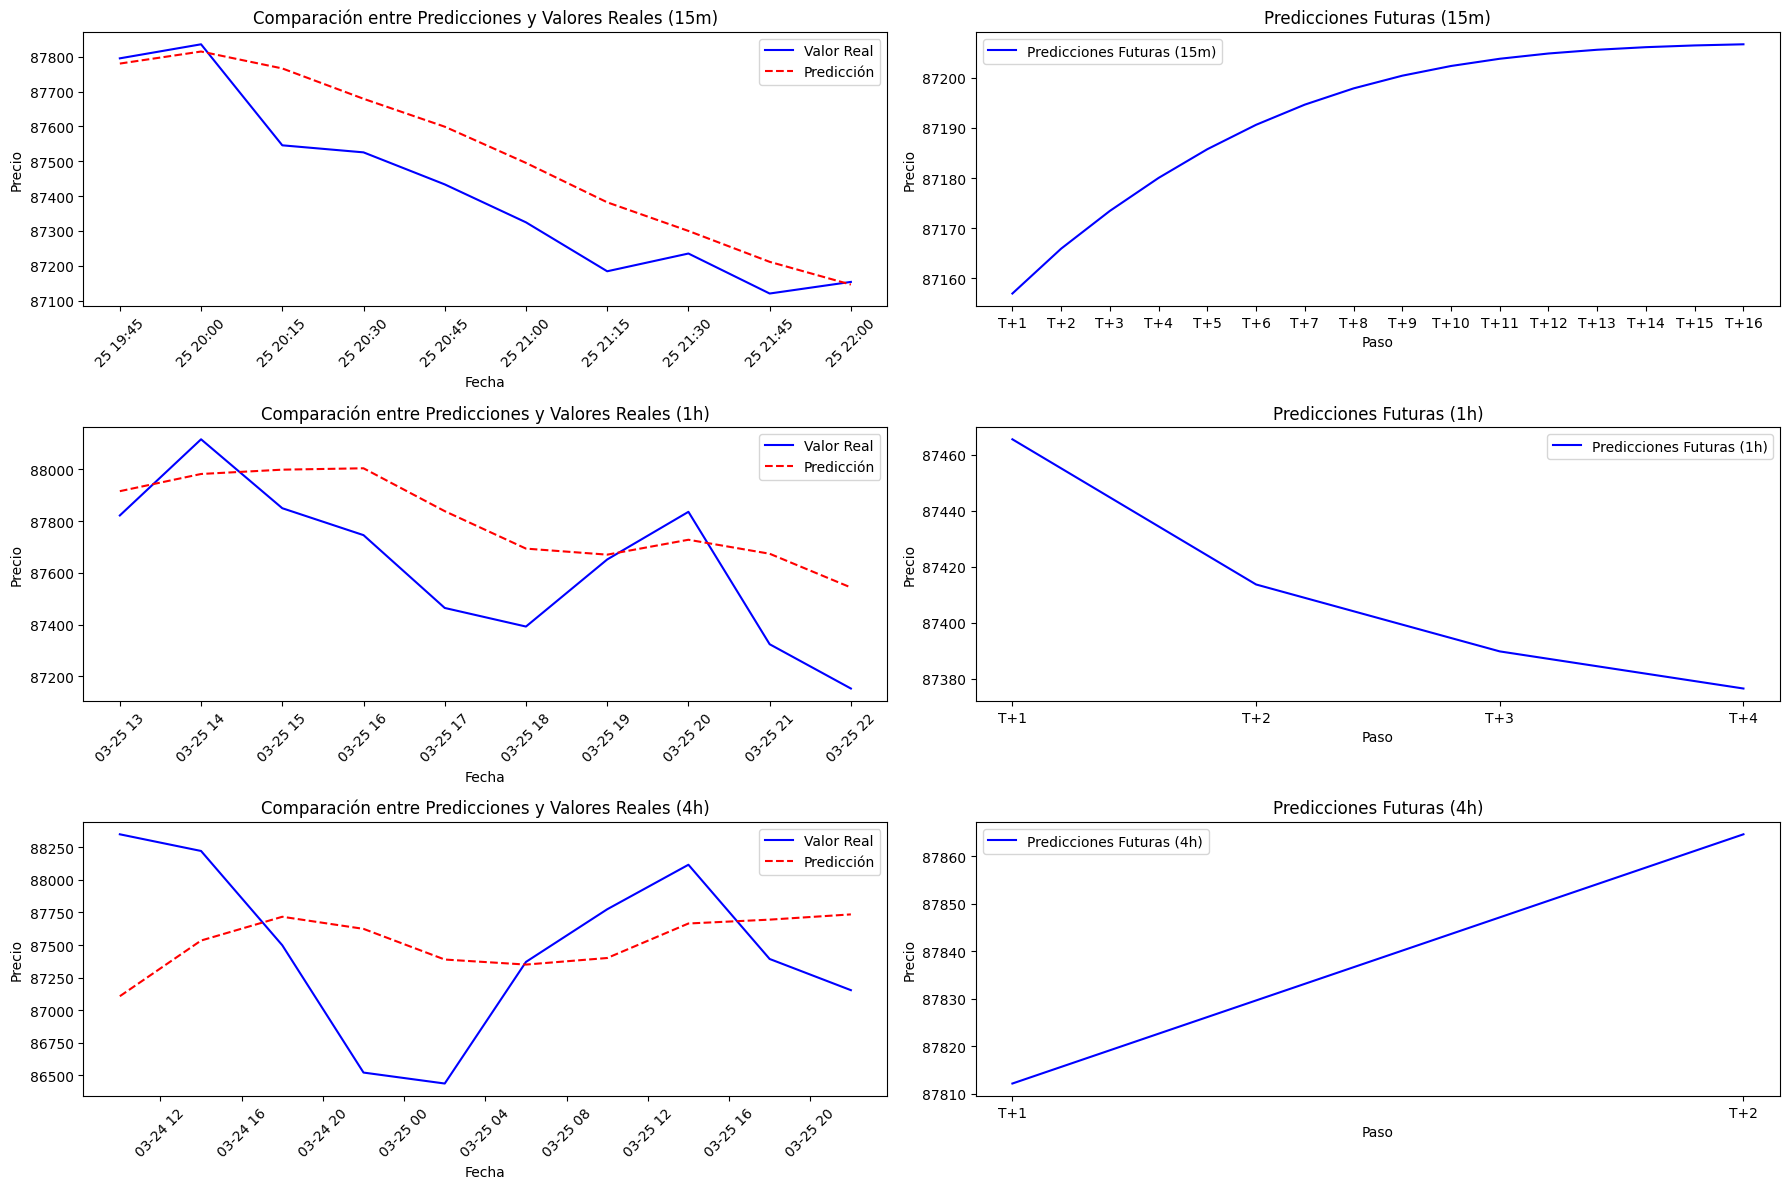

In [14]:
# Definir ruta del modelo LSTM
model_path = 'D:/YOP/web_page_geosierra/lstm_price_prediction_model.h5'

# Verificar si el modelo existe antes de cargarlo
if not os.path.exists(model_path):
    raise FileNotFoundError(f"El modelo {model_path} no fue encontrado.")

model = load_model(model_path)
print("Modelo cargado correctamente.")

# Convertir la columna 'datetime' a formato datetime asegurando que no haya problemas con zonas horarias
for df in [df_15m, df_1h, df_4h]:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)  # Eliminar filas con fechas inválidas
    df['datetime'] = df['datetime'].dt.tz_localize(None)  # Asegurar que sea tz-naive

# Función para crear secuencias para LSTM
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Función para predecir valores futuros
def predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler):
    last_sequence = data_scaled[-seq_length:]
    future_predictions = []

    for _ in range(num_predictions):
        input_sequence = np.reshape(last_sequence, (1, seq_length, num_features))
        next_prediction_scaled = model.predict(input_sequence)[0, 0]
        next_prediction_scaled = max(0, min(1, next_prediction_scaled))  # Evitar valores fuera de rango

        future_predictions.append(next_prediction_scaled)
        next_sequence = np.hstack((next_prediction_scaled, last_sequence[-1, 1:]))
        last_sequence = np.vstack((last_sequence[1:], next_sequence))

    future_predictions_actual = scaler.inverse_transform(
        np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((num_predictions, num_features - 1)))))[:, 0]

    return pd.DataFrame({'Paso': [f'T+{i+1}' for i in range(num_predictions)], 'Precio': future_predictions_actual})

# Función para evaluar un DataFrame con el modelo LSTM
def evaluate_dataframe(df, seq_length, num_predictions):
    try:
        # Seleccionar columnas relevantes
        df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].dropna()
        data_numeric = df[['open', 'high', 'low', 'close', 'volume']]

        # Escalar los datos
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_scaled = scaler.fit_transform(data_numeric)

        # Crear secuencias
        x, y = create_sequences(data_scaled, seq_length)

        # Dividir en entrenamiento y prueba
        train_size = int(len(x) * 0.8)
        x_train, y_train = x[:train_size], y[:train_size]
        x_test, y_test = x[train_size:], y[train_size:]

        num_features = data_numeric.shape[1]
        x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], num_features))

        # Predicciones en los datos de prueba
        y_pred = model.predict(x_test)
        y_pred = y_pred[:len(y_test)]

        # Desescalar los valores reales y predicciones
        y_test_actual = scaler.inverse_transform(
            np.hstack((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], num_features - 1)))))[:, 0]

        y_pred_actual = scaler.inverse_transform(
            np.hstack((y_pred.reshape(-1, 1), np.zeros((y_pred.shape[0], num_features - 1)))))[:, 0]

        # Guardar predicciones
        predictions_df = pd.DataFrame({
            'Fecha': df['datetime'].iloc[train_size + seq_length: train_size + seq_length + len(y_pred)].values,
            'Real': y_test_actual,
            'Predicción': y_pred_actual
        })

        # Predicciones futuras
        future_predictions_df = predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler)

        return predictions_df, future_predictions_df

    except Exception as e:
        print(f"Error al evaluar el DataFrame: {e}")
        return None, None

# Parámetros de predicción
seq_length = 50
intervals = {
    '15m': (df_15m, 16),
    '1h': (df_1h, 4),
    '4h': (df_4h, 2),
}

# Evaluar y graficar resultados
fig, axs = plt.subplots(3, 2, figsize=(18, 12))

for i, (label, (df, num_predictions)) in enumerate(intervals.items()):
    predictions_df, future_predictions_df = evaluate_dataframe(df, seq_length, num_predictions)

    if predictions_df is not None:
        # Graficar comparación entre valores reales y predicciones
        axs[i, 0].plot(predictions_df['Fecha'], predictions_df['Real'], label='Valor Real', color='blue')
        axs[i, 0].plot(predictions_df['Fecha'], predictions_df['Predicción'], label='Predicción', color='red', linestyle='--')
        axs[i, 0].set_title(f'Comparación entre Predicciones y Valores Reales ({label})')
        axs[i, 0].set_xlabel('Fecha')
        axs[i, 0].set_ylabel('Precio')
        axs[i, 0].legend()
        axs[i, 0].tick_params(axis='x', rotation=45)

        # Graficar predicciones futuras
        axs[i, 1].plot(future_predictions_df['Paso'], future_predictions_df['Precio'], label=f'Predicciones Futuras ({label})', color='blue')
        axs[i, 1].set_title(f'Predicciones Futuras ({label})')
        axs[i, 1].set_xlabel('Paso')
        axs[i, 1].set_ylabel('Precio')
        axs[i, 1].legend()

plt.tight_layout()
plt.show()
